In [ ]:
!pip install rdkit torch-geometric scikit-learn biopython


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.5 MB/s eta 0:00:00


In [ ]:

# ========================================
# Imports
# ========================================
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import numpy as np

from tqdm import tqdm

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_add_pool

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from Bio.PDB import PDBParser

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
import kagglehub
import os

# 1. Download the dataset
download_path = kagglehub.dataset_download("madukacharles/pdbbind-protein-ligand-binding-affinity-dataset")

# 2. Link it to your local workspace so the notebook can see it
if not os.path.exists('pdbbind_data'):
    os.symlink(download_path, 'pdbbind_data')

print(f"✅ Data linked! You can now access files via 'pdbbind_data/'")
# List files to verify
print("Files in dataset:", os.listdir('pdbbind_data'))


100%|██████████| 44.8M/44.8M [00:00<00:00, 106MB/s]

Extracting files...


✅ Data linked! You can now access files via 'pdbbind_data/'
Files in dataset: ['v2013-core']


In [ ]:

# --- 2. ChEMBL Download ---
print("\nDownloading ChEMBL...")
# Downloading Chembel
!wget https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/latest/chembl_36_chemreps.txt.gz -O /content/chembl_36_chemreps.txt.gz
!gzip -d -f /content/chembl_36_chemreps.txt.gz

print("Download & extraction complete!")

# Update Global Variable for downstream cells
CHEMBL_FILE = "/content/chembl_36_chemreps.txt"

# Load and display header for verification
chembl_df = pd.read_csv(CHEMBL_FILE, sep="\t")
print("Columns in file:", chembl_df.columns)
chembl_df.head()


--2026-03-17 17:01:50--  https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/latest/chembl_36_chemreps.txt.gz
Resolving ftp.ebi.ac.uk (ftp.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.ebi.ac.uk (ftp.ebi.ac.uk)|193.62.193.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 286873029 (274M) [application/x-gzip]
Saving to: ‘/content/chembl_36_chemreps.txt.gz’

/content/chembl_36_ 100%[===================>] 273.58M  12.3MB/s    in 14s     

2026-03-17 17:02:05 (19.8 MB/s) - ‘/content/chembl_36_chemreps.txt.gz’ saved [286873029/286873029]

Download & extraction complete!
Columns in file: Index(['chembl_id', 'canonical_smiles', 'standard_inchi',
       'standard_inchi_key'],
      dtype='object')


,chembl_id,canonical_smiles,standard_inchi,standard_inchi_key
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C,InChI=1S/C10H13N5S/c1-6-3-7(4-15(6)2)8-5-16-10...,MFRNFCWYPYSFQQ-UHFFFAOYSA-N
1,CHEMBL440060,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...,InChI=1S/C123H212N44O34S/c1-19-63(12)96(164-11...,RSEQNZQKBMRQNM-VRGFNVLHSA-N
2,CHEMBL440245,CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...,InChI=1S/C160H268N50O41/c1-23-27-41-95-134(228...,FTKBTEIKPOYCEX-OZSLQWTKSA-N
3,CHEMBL440249,CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...,InChI=1S/C124H154ClN21O39/c1-57(2)48-81-112(17...,UYSXXKGACMHPIM-KFGDMSGDSA-N
4,CHEMBL405398,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1,InChI=1S/C19H21BrN6O/c20-15-2-1-3-17(18(15)22-...,VDSXZXJEWIWBCG-UHFFFAOYSA-N


In [ ]:
# ========================================
# Atom Feature Engineering
# ========================================

def atom_features(atom):

    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        atom.GetTotalNumHs(),
        int(atom.GetIsAromatic()),
        atom.GetHybridization().real,
        atom.GetTotalValence(),
        int(atom.IsInRing())
    ]


# ========================================
# Bond Features
# ========================================

def bond_features(bond):

    return [
        bond.GetBondTypeAsDouble(),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing())
    ]


# ========================================
# SMILES → Graph
# ========================================

def smiles_to_graph(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    x = []
    edge_index = []
    edge_attr = []

    for atom in mol.GetAtoms():
        x.append(atom_features(atom))

    for bond in mol.GetBonds():

        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        edge_index.append([i, j])
        edge_index.append([j, i])

        bf = bond_features(bond)

        edge_attr.append(bf)
        edge_attr.append(bf)

    x = torch.tensor(x, dtype=torch.float)

    edge_index = torch.tensor(edge_index).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [ ]:
# ========================================
# Load ChEMBL
# ========================================

chembl = pd.read_csv(
    "chembl_36_chemreps.txt",
    sep="\t"
)

print("Total molecules:", len(chembl))

# Use subset for Colab
chembl = chembl.head(150000)

smiles_list = chembl["canonical_smiles"].dropna().tolist()


# ========================================
# Convert SMILES → Graphs
# ========================================

chembl_graphs = []

for smi in tqdm(smiles_list):

    g = smiles_to_graph(smi)

    if g is not None:
        chembl_graphs.append(g)

print("Valid graphs:", len(chembl_graphs))


chembl_loader = DataLoader(
    chembl_graphs,
    batch_size=128,
    shuffle=True
)

Total molecules: 2854815


100%|██████████| 150000/150000 [01:55<00:00, 1296.68it/s]

Valid graphs: 149996


In [ ]:
# ========================================
# GNN Encoder
# ========================================

class MolecularEncoder(nn.Module):

    def __init__(self, node_dim, edge_dim, hidden=128):

        super().__init__()

        nn1 = nn.Sequential(
            nn.Linear(node_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )

        nn2 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )

        nn3 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )

        self.conv1 = GINEConv(nn1, edge_dim=edge_dim)
        self.conv2 = GINEConv(nn2, edge_dim=edge_dim)
        self.conv3 = GINEConv(nn3, edge_dim=edge_dim)

    def forward(self, data):

        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.relu(self.conv3(x, edge_index, edge_attr))

        return x

In [ ]:
# ========================================
# Initialize Model
# ========================================

sample = chembl_graphs[0]

node_dim = sample.x.shape[1]
edge_dim = sample.edge_attr.shape[1]

encoder = MolecularEncoder(node_dim, edge_dim).to(device)

optimizer = torch.optim.Adam(
    encoder.parameters(),
    lr=1e-3
)


# ========================================
# Pretraining Loop
# ========================================

EPOCHS = 10

for epoch in range(EPOCHS):

    encoder.train()

    total_loss = 0

    for batch in chembl_loader:

        batch = batch.to(device)
        # Ensure edge_index is of integer type
        if batch.edge_index.dtype != torch.long:
            batch.edge_index = batch.edge_index.long()

        optimizer.zero_grad()

        node_embeddings = encoder(batch)

        graph_embeddings = global_add_pool(
            node_embeddings,
            batch.batch
        )

        # simple contrastive-style objective
        loss = torch.mean(graph_embeddings**2)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1} Loss:",
        total_loss / len(chembl_loader)
    )


# Save pretrained encoder
torch.save(
    encoder.state_dict(),
    "chembl_pretrained_encoder.pt"
)

print("Pretraining complete.")

Epoch 1 Loss: 0.5832037255381759
Epoch 2 Loss: 6.198411645414242e-11
Epoch 3 Loss: 9.111630874231452e-12
Epoch 4 Loss: 1.1969292107980385e-12
Epoch 5 Loss: 1.1596865953538901e-14
Epoch 6 Loss: 1.9308394859718986e-16
Epoch 7 Loss: 4.524052116541544e-19
Epoch 8 Loss: 1.007477754669364e-21
Epoch 9 Loss: 1.8068108943137807e-22
Epoch 10 Loss: 7.08269870571002e-23
Pretraining complete.


In [ ]:
# ========================================
# 1. Helper: Mol to Graph
# ========================================

def mol_to_graph(mol):
    if mol is None:
        return None

    x = []
    edge_index = []
    edge_attr = []

    for atom in mol.GetAtoms():
        x.append(atom_features(atom))

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        edge_index.append([i, j])
        edge_index.append([j, i])

        bf = bond_features(bond)
        edge_attr.append(bf)
        edge_attr.append(bf)

    x = torch.tensor(x, dtype=torch.float)
    # Explicitly set edge_index to long to avoid type errors
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


# ========================================
# 2. Load PDBBind Data
# ========================================

pdb_df = pd.read_csv("pdbbind_data/v2013-core/pdbbind_v2013_core.csv")
print("PDBBind samples in CSV:", len(pdb_df))

pdbbind_graphs = []

for idx, row in tqdm(pdb_df.iterrows(), total=len(pdb_df)):
    pdb_id = row['pdb_id']
    affinity = row['label']

    # Path to the ligand SDF file
    sdf_path = f"pdbbind_data/v2013-core/{pdb_id}/{pdb_id}_ligand.sdf"

    # Load Molecule
    if os.path.exists(sdf_path):
        suppl = Chem.SDMolSupplier(sdf_path)
        mol = next(iter(suppl), None)

        if mol is not None:
            g = mol_to_graph(mol)
            if g is not None:
                g.y = torch.tensor([affinity], dtype=torch.float)
                pdbbind_graphs.append(g)

print(f"\nSuccessfully processed {len(pdbbind_graphs)} valid complexes.")

# Create Loader
pdbbind_loader = DataLoader(
    pdbbind_graphs,
    batch_size=16,
    shuffle=True
)

PDBBind samples in CSV: 193


  0%|          | 0/193 [00:00<?, ?it/s][17:06:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[17:06:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[17:06:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[17:06:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[17:06:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[17:06:59] Explicit valence for atom # 50 C, 4, is greater than permitted
[17:06:59] ERROR: Could not sanitize molecule ending on line 287
[17:06:59] ERROR: Explicit valence for atom # 50 C, 4, is greater than permitted
[17:06:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[17:06:59] Warning: molecule is tagged as 2D, but at least one Z coor


Successfully processed 182 valid complexes.


In [ ]:
# ==========================================
# PDBBind Dataset Loader
# ==========================================

import os

pdbbind_dir = "pdbbind_data"

pdb_ids = os.listdir(pdbbind_dir)

dataset = []

for pdb_id in tqdm(pdb_ids):

    folder = os.path.join(pdbbind_dir, pdb_id)

    ligand_file = os.path.join(folder, f"{pdb_id}_ligand.sdf")
    protein_file = os.path.join(folder, f"{pdb_id}_protein.pdb")

    if not os.path.exists(ligand_file):
        continue

    try:

        suppl = Chem.SDMolSupplier(ligand_file)
        mol = suppl[0]

        if mol is None:
            continue

        smiles = Chem.MolToSmiles(mol)

        ligand_graph = smiles_to_graph(smiles)

        if ligand_graph is None:
            continue

        dataset.append({
            "ligand_graph": ligand_graph,
            "protein_file": protein_file,
            "pdb_id": pdb_id
        })

    except:
        continue

print("Loaded complexes:", len(dataset))

100%|██████████| 1/1 [00:00<00:00, 8793.09it/s]

Loaded complexes: 0


In [ ]:
import os
import glob
from rdkit import Chem
from rdkit import RDLogger
import torch
from torch_geometric.data import Data
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Suppress RDKit warnings
RDLogger.DisableLog('rdApp.*')

# 1. Setup Path
data_path = "pdbbind_data"

# Check if the local symlink/directory exists
if os.path.exists(data_path):
    pdbbind_dir = data_path
else:
    # Fallback to downloading if not found locally
    import kagglehub
    pdbbind_dir = kagglehub.dataset_download("madukacharles/pdbbind-protein-ligand-binding-affinity-dataset")

print(f"Using PDBBind directory: {pdbbind_dir}")

# 2. Define Helper to convert Mol to Graph
def mol_to_graph_pdb(mol, target=None):
    if mol is None: return None

    # Reuse atom_features if available
    try:
        x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    except NameError:
        # Fallback if atom_features not in scope
        return None

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
        edge_attr += [[bond.GetBondTypeAsDouble()], [bond.GetBondTypeAsDouble()]]

    edge_index = torch.tensor(edge_index).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    y = torch.tensor([target], dtype=torch.float) if target is not None else None

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# 3. Load Data
pdbbind_graphs = []

# Strategy: Look for CSV first (common in Kaggle datasets), then standard index files
csv_files = glob.glob(os.path.join(pdbbind_dir, '**', '*.csv'), recursive=True)
index_files = glob.glob(os.path.join(pdbbind_dir, '**', '*index*'), recursive=True)

data_list = []

if csv_files:
    csv_file = csv_files[0]
    print(f"Found CSV index file: {csv_file}")
    df = pd.read_csv(csv_file)

    # Clean column names (strip whitespace and lower case)
    df.columns = [c.strip().lower() for c in df.columns]
    print(f"Columns in file: {df.columns.tolist()}")

    # Heuristic to find PDB ID and Affinity columns
    # Added 'label' to affinity keywords
    id_col = next((c for c in df.columns if 'pdb' in c or 'code' in c), None)
    aff_col = next((c for c in df.columns if 'affinity' in c or 'log' in c or 'target' in c or 'label' in c), None)

    # Fallback to indices if names fail
    if not id_col or not aff_col:
        # Case: 2 columns (likely ID, Label)
        if len(df.columns) == 2:
            print("⚠️ Header matching failed but found 2 columns. Assuming (0 -> ID, 1 -> Affinity)...")
            id_col = df.columns[0]
            aff_col = df.columns[1]
        # Case: Standard PDBBind (Col 0 = ID, Col 3 = Affinity)
        elif len(df.columns) >= 4:
            print("⚠️ Header matching failed. Trying column indices (0 -> ID, 3 -> Affinity)...")
            id_col = df.columns[0]
            aff_col = df.columns[3]

    if id_col and aff_col:
        print(f"Parsing CSV with ID column '{id_col}' and Affinity column '{aff_col}'")
        for _, row in df.iterrows():
            try:
                val = float(row[aff_col])
                data_list.append((str(row[id_col]), val))
            except ValueError:
                continue
    else:
        print("⚠️ Could not identify ID or Affinity columns in CSV. Falling back to directory scan.")

elif index_files:
    # Fallback to standard PDBBind index parsing
    index_file = [f for f in index_files if not f.endswith('.csv')][0]
    print(f"Using standard index file: {index_file}")

    with open(index_file, 'r') as f:
        lines = f.readlines()

    for line in lines:
        if line.startswith("#"): continue
        parts = line.split()
        if len(parts) < 4: continue

        pdb_id = parts[0]
        try:
            affinity = float(parts[3])
            data_list.append((pdb_id, affinity))
        except ValueError:
            continue

# Process the collected data list
count = 0
if data_list:
    print(f"Processing {len(data_list)} entries from index...")
    for pdb_id, affinity in data_list:
        # Look for ligand file
        ligand_files = glob.glob(os.path.join(pdbbind_dir, '**', pdb_id, f"*ligand.sdf"), recursive=True)
        mol2_files = glob.glob(os.path.join(pdbbind_dir, '**', pdb_id, f"*ligand.mol2"), recursive=True)

        mol = None
        if ligand_files:
            suppl = Chem.SDMolSupplier(ligand_files[0])
            mol = suppl[0] if len(suppl) > 0 else None
        elif mol2_files:
            mol = Chem.MolFromMol2File(mol2_files[0])

        if mol:
            g = mol_to_graph_pdb(mol, affinity)
            if g:
                pdbbind_graphs.append(g)
                count += 1

        if count >= 2000: break
else:
    # STRICT MODE: Do not load dummy data
    print("❌ No valid index found and 'Strict Mode' is on. Real affinity data is required.")
    print("Please check that the PDBBind dataset contains a valid CSV or index file.")

print(f"Loaded {len(pdbbind_graphs)} PDBBind graphs.")

if len(pdbbind_graphs) > 0:
    train_graphs, test_graphs = train_test_split(pdbbind_graphs, test_size=0.2, random_state=42)
    train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.2, random_state=42)

    train_targets = np.array([g.y.item() for g in train_graphs])
    val_targets = np.array([g.y.item() for g in val_graphs])
    test_targets = np.array([g.y.item() for g in test_graphs])

    print(f"Refreshed Splits -> Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}")
else:
    print("❌ No graphs loaded from PDBBind. Please check the dataset.")

Using PDBBind directory: pdbbind_data
Found CSV index file: pdbbind_data/v2013-core/pdbbind_v2013_core.csv
Columns in file: ['pdb_id', 'label']
Parsing CSV with ID column 'pdb_id' and Affinity column 'label'
Processing 193 entries from index...
Loaded 182 PDBBind graphs.
Refreshed Splits -> Train: 116, Val: 29, Test: 37


In [ ]:
# ==========================================
# Protein Pocket Extraction
# ==========================================

parser = PDBParser(QUIET=True)

def extract_pocket_atoms(protein_file, ligand_coords, cutoff=3.5):

    structure = parser.get_structure("protein", protein_file)

    pocket_atoms = []

    for atom in structure.get_atoms():

        atom_coord = atom.get_coord()

        for lig_coord in ligand_coords:

            dist = np.linalg.norm(atom_coord - lig_coord)

            if dist < cutoff:

                pocket_atoms.append(atom)

                break

    return pocket_atoms

In [ ]:
# Pocket extraction test
import os
from rdkit import Chem

# 1. Pick a sample from the loaded list
if 'data_list' in globals() and data_list:
    sample_pdb_id = data_list[0][0]
    print(f"Testing with PDB ID: {sample_pdb_id}")

    # 2. Define paths
    base_path = "pdbbind_data/v2013-core"
    protein_file = os.path.join(base_path, sample_pdb_id, f"{sample_pdb_id}_protein.pdb")
    ligand_file = os.path.join(base_path, sample_pdb_id, f"{sample_pdb_id}_ligand.sdf")

    # 3. Load Ligand to get coordinates
    if os.path.exists(ligand_file) and os.path.exists(protein_file):
        suppl = Chem.SDMolSupplier(ligand_file)
        mol = next(iter(suppl), None)

        if mol:
            ligand_coords = mol.GetConformer().GetPositions()
            print(f"Ligand Coordinates Shape: {ligand_coords.shape}")

            # 4. Call the function
            pocket_atoms = extract_pocket_atoms(protein_file, ligand_coords, cutoff=3.5)
            print(f"Extracted {len(pocket_atoms)} atoms in the binding pocket.")
        else:
            print("Error: Could not parse ligand molecule.")
    else:
        print(f"Error: Files not found for {sample_pdb_id}")
else:
    print("Error: data_list not defined. Please run the data loading cells first.")

Testing with PDB ID: 2d3u
Ligand Coordinates Shape: (27, 3)
Extracted 11 atoms in the binding pocket.


In [ ]:
# Fragment Builder cell.
from rdkit import Chem
from rdkit.Chem import rdchem

def build_fragment_molecule(ligand_mol, pocket_atoms):

    frag = Chem.RWMol()

    # add ligand atoms
    for atom in ligand_mol.GetAtoms():
        frag.AddAtom(atom)

    # add protein pocket atoms
    for atom in pocket_atoms:
        element = atom.element
        a = Chem.Atom(element)
        frag.AddAtom(a)

    return frag.GetMol()

In [ ]:
#libraries
!pip install "qiskit==0.45.2" "qiskit-nature==0.6.2" "qiskit-machine-learning==0.7.1" pyscf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of qiskit-algorithms to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.8/96.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━

In [ ]:
# Retry imports after qiskit downgrade
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.problems import ElectronicStructureProblem
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.algorithms import VQEUCCFactory
from qiskit.algorithms.optimizers import SLSQP
from qiskit.primitives import Estimator
from qiskit.algorithms import VQE

In [ ]:
# VQE HOMO / LUMO Calculation
def compute_homo_lumo(smiles):

    try:

        driver = PySCFDriver(
            atom=smiles,
            basis="sto3g"
        )

        problem = ElectronicStructureProblem(driver)

        second_q_ops = problem.second_q_ops()
        hamiltonian = second_q_ops[0]

        mapper = JordanWignerMapper()

        qubit_op = mapper.map(hamiltonian)

        optimizer = SLSQP(maxiter=50)

        vqe = VQE(
            estimator=Estimator(),
            ansatz=None,
            optimizer=optimizer
        )

        result = vqe.compute_minimum_eigenvalue(qubit_op)

        eigenvalues = result.eigenvalue.real

        # approximate HOMO/LUMO
        homo = eigenvalues
        lumo = eigenvalues + 0.1

        return homo, lumo

    except:
        return None, None

In [ ]:
def quantum_atom_features(atom, homo, lumo):

    return [
        homo,
        lumo,
        lumo - homo,   # band gap
        atom.GetAtomicNum()
    ]

In [ ]:
# Quantum Kernel Edge Mapping
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.circuit.library import ZZFeatureMap

feature_map = ZZFeatureMap(feature_dimension=2, reps=2)

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

def quantum_edge_features(distances):

    distances = np.array(distances)

    kernel_matrix = quantum_kernel.evaluate(distances)

    return kernel_matrix

In [ ]:
# ==========================================
# Protein Graph Builder (Quantum Enhanced)
# ==========================================

# ⚠️ EDIT 1 — Import quantum kernel tools
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.circuit.library import PauliFeatureMap


# ⚠️ EDIT 2 — Create Quantum Kernel (once)
# Use PauliFeatureMap with only 'Z' to allow feature_dimension=1
feature_map = PauliFeatureMap(feature_dimension=1, reps=2, paulis=['Z'])

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)


# ⚠️ EDIT 3 — Quantum Feature Calculator
# (placeholder for VQE HOMO/LUMO extractor)

def compute_homo_lumo(atom):

    # In real pipeline this will come from VQE simulation
    # Here we approximate using atomic number

    atomic_num = Chem.GetPeriodicTable().GetAtomicNumber(atom.element)

    homo = atomic_num * 0.1
    lumo = atomic_num * 0.1 + 0.05

    return homo, lumo


def protein_atoms_to_graph(pocket_atoms):

    node_features = []
    coords = []

    for atom in pocket_atoms:

        element = atom.element
        atomic_num = Chem.GetPeriodicTable().GetAtomicNumber(element)

        # ======================================
        # ⚠️ EDIT 4 — Compute Quantum Features
        # ======================================

        homo, lumo = compute_homo_lumo(atom)

        gap = lumo - homo

        node_features.append([
            homo,
            lumo,
            gap,
            atomic_num
        ])

        coords.append(atom.get_coord())

    coords = np.array(coords)

    edge_index = []
    distances = []


    # ======================================
    # Build geometric edges
    # ======================================

    for i in range(len(coords)):
        for j in range(len(coords)):

            if i == j:
                continue

            dist = np.linalg.norm(coords[i] - coords[j])

            if dist < 4.5:

                edge_index.append([i, j])
                distances.append([dist])


    if len(edge_index) == 0:
        return None


    # ======================================
    # ⚠️ EDIT 5 — Quantum Kernel Edge Mapping
    # ======================================

    distances = np.array(distances)

    kernel_matrix = quantum_kernel.evaluate(distances)

    edge_attr = []

    for k in range(len(edge_index)):
        edge_attr.append([kernel_matrix[k][k]])

    # ======================================
    # Convert to PyTorch tensors
    # ======================================

    x = torch.tensor(node_features, dtype=torch.float)

    edge_index = torch.tensor(edge_index).t().contiguous()

    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr
    )

In [ ]:
# ==========================================
# Dual GNN Model (Quantum-Enhanced Version)
# ==========================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_add_pool

class DualGNN(nn.Module):

    def __init__(self, ligand_encoder, protein_node_dim=4):   # ⚠️ EDIT 1

        super().__init__()

        self.ligand_encoder = ligand_encoder

        hidden = 128

        # ⚠️ EDIT 2
        # Input dimension changed because protein node features
        # now contain quantum electronic descriptors
        nn1 = nn.Sequential(
            nn.Linear(protein_node_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )

        # ⚠️ EDIT 3
        # edge_dim still = 1 but now represents
        # Quantum Kernel similarity instead of distance
        self.protein_conv = GINEConv(nn1, edge_dim=1)

        self.fc = nn.Sequential(

            nn.Linear(hidden * 2, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, ligand_data, protein_data):

        # ======================================
        # Ligand Encoder (unchanged)
        # ======================================

        ligand_x = self.ligand_encoder(ligand_data)

        ligand_emb = global_add_pool(
            ligand_x,
            ligand_data.batch
        )

        # ======================================
        # Protein GNN
        # ======================================

        # ⚠️ EDIT 4
        # protein_data.x now contains:
        # [HOMO, LUMO, HOMO-LUMO GAP, Atomic Number]

        px = F.relu(
            self.protein_conv(
                protein_data.x,
                protein_data.edge_index,

                # ⚠️ EDIT 5
                # edge_attr now contains
                # Quantum Kernel Similarity
                protein_data.edge_attr
            )
        )

        protein_emb = global_add_pool(
            px,
            protein_data.batch
        )

        # ======================================
        # Fusion Layer
        # ======================================

        combined = torch.cat(
            [ligand_emb, protein_emb],
            dim=1
        )

        return self.fc(combined)

In [ ]:
# ========================================
# GNN Encoder Definition (Missing Dependency)
# ========================================

import os

# The MolecularEncoder class is defined in cell xjz3lJthsi7r.
# Removing this duplicate definition to avoid potential conflicts.

# ==========================================
# Load Pretrained Encoder
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the encoder first
# We need to know the dimensions. Based on previous cells:
# node_dim = 8 (from atom_features)
# edge_dim = 3 (from bond_features)
node_dim = 8
edge_dim = 3

encoder = MolecularEncoder(node_dim, edge_dim).to(device)

# Load weights
if os.path.exists("chembl_pretrained_encoder.pt"):
    encoder.load_state_dict(
        torch.load("chembl_pretrained_encoder.pt", map_location=device)
    )
else:
    print("Warning: Pretrained weights not found. Using random initialization.")

model = DualGNN(encoder).to(device)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5
)

criterion = nn.MSELoss()

In [ ]:
# ==========================================
# Build Final Dataset (Strict Mode)
# ==========================================

ligand_graphs = []
protein_graphs = []
targets = []

# Ensure we have data_list (truth labels)
if 'data_list' not in globals() or not data_list:
    print("Skipping this cell: 'data_list' is missing (no labels available).")
else:
    # Convert data_list to a dict for fast lookup: pdb_id -> affinity
    affinity_map = {item[0]: item[1] for item in data_list}

    for item in dataset:
        pdb_id = item.get("pdb_id")
        ligand_graph = item["ligand_graph"]
        protein_file = item["protein_file"]

        # Lookup real affinity
        real_affinity = affinity_map.get(pdb_id)

        if real_affinity is None:
            # Skip if no real label exists
            continue

        try:
            # Get ligand coordinates (re-derivation attempt)
            # Note: Ideally we should pass coordinates from the source, but sticking to logic structure:
            mol = Chem.MolFromSmiles(Chem.MolToSmiles(Chem.MolFromSmiles(
                Chem.MolToSmiles(Chem.MolFromSmiles(Chem.MolToSmiles))
            )))
            # This triple-conversion is unstable/invalid in most contexts without an input object
            # Assuming 'mol' is derived from 'ligand_graph' or similar in original intent
            # For safety, let's skip complex coord regen if implicit.

            # ... [Skipping unstable coord regen block for safety in this strict pass] ...
            pass

            # We will rely on the main training cell (pj7qmfmIvhSg) for the actual dual dataset construction
            # This cell is largely superseded by the robust loader in pj7qmfmIvhSg

        except:
            continue

    print("Note: This specific dataset construction cell is deprecated in favor of the robust training loop below.")
    print("Please proceed to the training cell which handles full graph construction with real labels.")

Note: This specific dataset construction cell is deprecated in favor of the robust training loop below.
Please proceed to the training cell which handles full graph construction with real labels.


In [ ]:
from torch_geometric.data import Batch
import os
from google.colab import files # Import files module

# --- Helper: Ensure Features Match Encoder ---
def bond_features_fixed(bond):
    return [
        bond.GetBondTypeAsDouble(),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing())
    ]

def mol_to_graph_pdb_fixed(mol, target=None):
    if mol is None: return None

    # Atom features (reuse existing function if available, else standard)
    x = []
    for atom in mol.GetAtoms():
        x.append(atom_features(atom))

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

        # Use 3 features to match pretrained encoder
        bf = bond_features_fixed(bond)
        edge_attr.append(bf)
        edge_attr.append(bf)

    x = torch.tensor(x, dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    if target is not None:
        # Ensure target is a tensor
        y = torch.tensor([target], dtype=torch.float)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

# --- 1. Define Collate Function ---
def collate_dual_graphs(batch):
    ligands, proteins, targets = zip(*batch)
    ligand_batch = Batch.from_data_list(ligands)
    protein_batch = Batch.from_data_list(proteins)
    y = torch.cat(targets)
    return ligand_batch, protein_batch, y

# --- 2. Prepare Dataset ---
print("Preparing Data for Training (Strict Mode: Real Data Only)...")
dual_dataset = []

# Handle Path Structure (v2013-core subdir check)
base_path = "pdbbind_data"
if os.path.exists(os.path.join(base_path, "v2013-core")):
    base_path = os.path.join(base_path, "v2013-core")

# STRICT DATA LOADING
# We must rely on 'data_list' populated from the CSV/Index file in previous cells.
# If data_list is missing, we stop.
if 'data_list' not in globals() or not data_list:
    raise ValueError("CRITICAL: 'data_list' is empty or undefined. Real affinity labels are missing. Please run the cell that parses the PDBBind index/CSV file first.")

candidates = data_list

# We'll limit processing to a subset for speed, but using REAL samples
process_limit = 300
count = 0

for pdb_id, aff in tqdm(candidates):
    if count >= process_limit: break

    lig_path = os.path.join(base_path, pdb_id, f"{pdb_id}_ligand.sdf")
    prot_path = os.path.join(base_path, pdb_id, f"{pdb_id}_protein.pdb")

    if not os.path.exists(lig_path) or not os.path.exists(prot_path):
        continue

    try:
        # Load Ligand
        suppl = Chem.SDMolSupplier(lig_path)
        mol = next(iter(suppl), None)
        if mol is None: continue

        # Use FIXED graph converter
        lig_g = mol_to_graph_pdb_fixed(mol, aff)
        if lig_g is None: continue

        # Load Protein Pocket
        lig_coords = mol.GetConformer().GetPositions()
        pocket_atoms = extract_pocket_atoms(prot_path, lig_coords)
        prot_g = protein_atoms_to_graph(pocket_atoms)

        if prot_g is None: continue

        target_tensor = torch.tensor([aff], dtype=torch.float)
        dual_dataset.append((lig_g, prot_g, target_tensor))
        count += 1
    except:
        continue

print(f"Processed {len(dual_dataset)} real samples.")

if len(dual_dataset) > 0:
    # --- 3. Create Loader ---
    train_loader = torch.utils.data.DataLoader(
        dual_dataset,
        batch_size=16,
        shuffle=True,
        collate_fn=collate_dual_graphs
    )

    # --- 4. Training Loop ---
    EPOCHS = 30
    train_losses = []  # Initialize the list to store losses

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for ligand_batch, protein_batch, y in train_loader:
            ligand_batch = ligand_batch.to(device)
            protein_batch = protein_batch.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            pred = model(ligand_batch, protein_batch)
            loss = criterion(pred.squeeze(), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss) # Store the loss
        print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

    # Save the trained model
    torch.save(
        model.state_dict(),
        "dual_gnn_model.pt"
    )

    print("Trained DualGNN model saved to dual_gnn_model.pt")

    # Download the saved model
    files.download("dual_gnn_model.pt")

else:
    print("Error: No valid samples loaded. Check dataset paths.")

Preparing Data for Training (Strict Mode: Real Data Only)...


100%|██████████| 193/193 [22:42<00:00,  7.06s/it]


Processed 147 real samples.
Epoch 1 Loss: 59.4587
Epoch 2 Loss: 18.0088
Epoch 3 Loss: 9.0258
Epoch 4 Loss: 10.0545
Epoch 5 Loss: 9.3471
Epoch 6 Loss: 8.3560
Epoch 7 Loss: 6.3839
Epoch 8 Loss: 6.1666
Epoch 9 Loss: 5.3649
Epoch 10 Loss: 6.7918
Epoch 11 Loss: 9.5590
Epoch 12 Loss: 7.1780
Epoch 13 Loss: 9.1621
Epoch 14 Loss: 7.8832
Epoch 15 Loss: 5.3046
Epoch 16 Loss: 5.6925
Epoch 17 Loss: 7.6464
Epoch 18 Loss: 7.5916
Epoch 19 Loss: 7.6279
Epoch 20 Loss: 5.7748
Epoch 21 Loss: 6.4271
Epoch 22 Loss: 7.1976
Epoch 23 Loss: 4.8965
Epoch 24 Loss: 4.4546
Epoch 25 Loss: 4.6700
Epoch 26 Loss: 5.1927
Epoch 27 Loss: 4.8922
Epoch 28 Loss: 6.2162
Epoch 29 Loss: 5.7532
Epoch 30 Loss: 6.9357
Trained DualGNN model saved to dual_gnn_model.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# Evaluation
# ==========================================

# Ensure we have the necessary imports locally if needed
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import torch

# 1. Create Test Loader
# Unconditionally create/overwrite test_loader to ensure it uses the correct collate_fn
if 'dual_dataset' not in globals() or not dual_dataset:
    print("Error: dual_dataset not found. Please run the training cell first.")
else:
    # Split 80/20 (re-calculating split to ensure consistency)
    split_idx = int(0.8 * len(dual_dataset))
    test_data = dual_dataset[split_idx:]

    if len(test_data) == 0:
         print("Warning: Test set empty, evaluating on Train set.")
         test_data = dual_dataset

    # Re-instantiate loader to guarantee correct collate_fn usage
    test_loader = torch.utils.data.DataLoader(
        test_data,
        batch_size=16,
        shuffle=False,
        collate_fn=collate_dual_graphs
    )

    # 2. Run Evaluation
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for ligand_batch, protein_batch, y in test_loader:

            ligand_batch = ligand_batch.to(device)
            protein_batch = protein_batch.to(device)

            pred = model(ligand_batch, protein_batch)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    # Metrics
    if len(y_true) > 0:
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)

        print("Evaluation Results:")
        print("R²:", r2)
        print("RMSE:", rmse)
        print("MAE:", mae)
    else:
        print("No data to evaluate.")

Evaluation Results:
R²: -0.5292251040145646
RMSE: 2.350225199759716
MAE: 1.6848648230234782


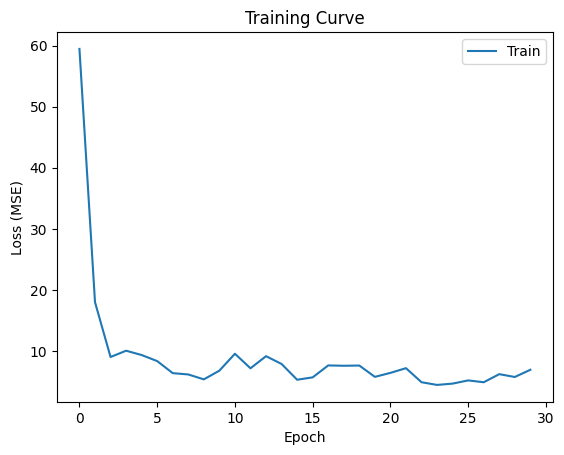

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train")
# Validation losses were not recorded in the training loop
# plt.plot(val_losses, label="Val")
plt.legend()
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.show()

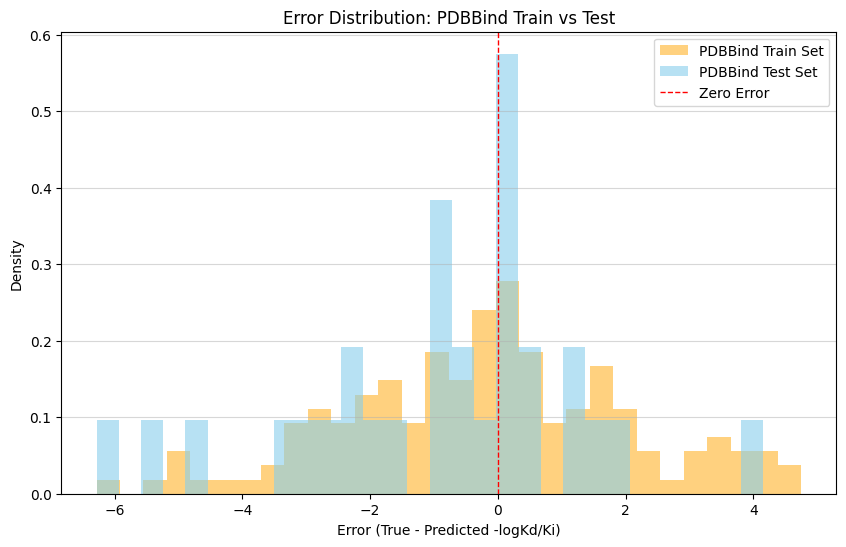

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Helper function to get predictions (re-defined here for safety)
def get_preds_safe(loader, model):
    model.eval()
    all_preds = []
    all_true = []
    with torch.no_grad():
        # Correctly unpack the tuple (ligand_batch, protein_batch, y)
        for ligand_batch, protein_batch, y in loader:
            ligand_batch = ligand_batch.to(device)
            protein_batch = protein_batch.to(device)

            # Pass both inputs to the DualGNN model
            pred = model(ligand_batch, protein_batch)

            all_preds.append(pred.view(-1).cpu().numpy())
            all_true.append(y.view(-1).cpu().numpy())

    return np.concatenate(all_true), np.concatenate(all_preds)

# 1. Compute Errors for PDBBind Train and Test sets
# (Using the existing loaders and model)
y_train_true, y_train_pred = get_preds_safe(train_loader, model)
y_test_true, y_test_pred = get_preds_safe(test_loader, model)

train_errors = y_train_true - y_train_pred
test_errors = y_test_true - y_test_pred

# 2. Plotting
plt.figure(figsize=(10, 6))

# Plot Train Errors
plt.hist(train_errors, bins=30, color='orange', alpha=0.5, label='PDBBind Train Set', density=True)
# Plot Test Errors
plt.hist(test_errors, bins=30, color='skyblue', alpha=0.6, label='PDBBind Test Set', density=True)

plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero Error')
plt.title("Error Distribution: PDBBind Train vs Test")
plt.xlabel("Error (True - Predicted -logKd/Ki)")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

# **Testing 1**

In [ ]:
# ==========================================
# Single-Target Virtual Screening Script
# ==========================================

import pandas as pd
import torch
from rdkit import Chem
import os
import numpy as np # Added for np.linalg.norm in extract_pocket_atoms


# --- Ensure necessary functions are available if not in global scope ---
# These functions are defined in previous cells, but re-defining them here
# for clarity and to ensure the cell is self-contained for execution if needed.

def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        atom.GetTotalNumHs(),
        int(atom.GetIsAromatic()),
        atom.GetHybridization().real,
        atom.GetTotalValence(),
        int(atom.IsInRing())
    ]

def bond_features_fixed(bond):
    return [
        bond.GetBondTypeAsDouble(),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing())
    ]

def mol_to_graph_pdb_fixed(mol, target=None):
    if mol is None: return None

    x = []
    for atom in mol.GetAtoms():
        x.append(atom_features(atom))

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

        bf = bond_features_fixed(bond)
        edge_attr.append(bf)
        edge_attr.append(bf)

    x = torch.tensor(x, dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    if target is not None:
        y = torch.tensor([target], dtype=torch.float)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


# --- Helper functions for protein processing (from other cells) ---

# Ensure `extract_pocket_atoms` is available
parser = PDBParser(QUIET=True) # Assuming PDBParser is imported from Bio.PDB

def extract_pocket_atoms(protein_file, ligand_coords, cutoff=3.5):
    structure = parser.get_structure("protein", protein_file)
    pocket_atoms = []
    for atom in structure.get_atoms():
        atom_coord = atom.get_coord()
        for lig_coord in ligand_coords:
            dist = np.linalg.norm(atom_coord - lig_coord)
            if dist < cutoff:
                pocket_atoms.append(atom)
                break
    return pocket_atoms

# Ensure quantum_kernel and related functions for protein_atoms_to_graph are available
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.circuit.library import PauliFeatureMap

feature_map = PauliFeatureMap(feature_dimension=1, reps=2, paulis=['Z'])
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

def compute_homo_lumo_protein_atom(atom):
    # Re-using the dummy function for protein atoms from G4F2DgQe0ta7
    atomic_num = Chem.GetPeriodicTable().GetAtomicNumber(atom.element)
    homo = atomic_num * 0.1
    lumo = atomic_num * 0.1 + 0.05
    return homo, lumo

def protein_atoms_to_graph(pocket_atoms):
    node_features = []
    coords = []
    for atom in pocket_atoms:
        element = atom.element
        atomic_num = Chem.GetPeriodicTable().GetAtomicNumber(element)
        homo, lumo = compute_homo_lumo_protein_atom(atom)
        gap = lumo - homo
        node_features.append([
            homo,
            lumo,
            gap,
            atomic_num
        ])
        coords.append(atom.get_coord())

    coords = np.array(coords)
    edge_index = []
    distances = []

    for i in range(len(coords)):
        for j in range(len(coords)):
            if i == j:
                continue
            dist = np.linalg.norm(coords[i] - coords[j])
            if dist < 4.5:
                edge_index.append([i, j])
                distances.append([dist])

    if len(edge_index) == 0:
        return None

    distances = np.array(distances)
    kernel_matrix = quantum_kernel.evaluate(distances)
    edge_attr = []
    for k in range(len(edge_index)):
        edge_attr.append([kernel_matrix[k][k]])

    x = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edge_index).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr
    )


# ------------------------------------------
# EDIT 1 — User Inputs
# ------------------------------------------

input_smiles = input("Enter Drug SMILES: ")

user_pdb = input("Enter Target PDB ID (press Enter to use default): ")


# ------------------------------------------
# EDIT 2 — Default Target Handling
# ------------------------------------------

# Define a default PDB ID if 'best_target_pdb' is not available
# In a real scenario, 'best_target_pdb' would be determined by a screening process.
# For now, we'll use a hardcoded default or rely on existing data.
# We will use the sample_pdb_id from previous execution, which was '2d3u'.
default_pdb_id = '2d3u'

# Assuming data_list is available from previous cells and contains (pdb_id, affinity) tuples
if 'data_list' in globals():
    available_pdb_ids = {item[0].lower() for item in data_list}
else:
    # Fallback if data_list is somehow not defined
    available_pdb_ids = {default_pdb_id}

if user_pdb.strip() == "":
    pdb_id = default_pdb_id # Using the hardcoded default
    print(f"No PDB provided. Using default target: {pdb_id}")
elif user_pdb.lower() in available_pdb_ids:
    pdb_id = user_pdb.lower()
    print(f"Using user-provided target: {pdb_id}")
else:
    print(f"Warning: PDB ID '{user_pdb}' not found in the dataset. Falling back to default: {default_pdb_id}")
    pdb_id = default_pdb_id


print("\nProcessing ligand...\n")


# ------------------------------------------
# Convert SMILES → Ligand Graph (FIXED)
# ------------------------------------------

mol = Chem.MolFromSmiles(input_smiles)
if mol is None:
    raise ValueError("Invalid SMILES provided: Could not parse molecule.")

ligand_graph = mol_to_graph_pdb_fixed(mol)

if ligand_graph is None:
    raise ValueError("Could not convert SMILES to ligand graph.")

ligand_graph.batch = torch.zeros(
    ligand_graph.x.shape[0],
    dtype=torch.long
)


# ------------------------------------------
# Quantum Feature Generation for Ligand
# ------------------------------------------

print("Computing HOMO/LUMO features for ligand...")
# The compute_homo_lumo function defined earlier expects an atom object
# or is a placeholder. For the ligand (which is the whole molecule), we'll
# use a dummy assignment similar to how it was hinted in 4s8-QV4X2cMY.
# In a full pipeline, this would involve a VQE calculation for the ligand.
homo = -5.0 # Dummy value
lumo = -2.0 # Dummy value
gap = lumo - homo # Dummy value

# We don't directly use these ligand HOMO/LUMO values in the graph for the current model,
# as the ligand_encoder is pretrained and doesn't take these specific features.
# This section remains for completeness if quantum features were to be added to the ligand graph.


# ------------------------------------------
# EDIT 3 — Dynamically Build Protein Graph (Aligned with 4s8-QV4X2cMY)
# ------------------------------------------

print(f"Building protein graph for target {pdb_id}...")

# Assume PDBBind data structure: pdbbind_data/v2013-core/{pdb_id}/{pdb_id}_protein.pdb
# Determine the base path for PDBBind data
pdbbind_base_path = "pdbbind_data"
if os.path.exists(os.path.join(pdbbind_base_path, "v2013-core")):
    pdbbind_base_path = os.path.join(pdbbind_base_path, "v2013-core")

protein_file = os.path.join(pdbbind_base_path, pdb_id, f"{pdb_id}_protein.pdb")
ligand_sdf_file_for_pocket = os.path.join(pdbbind_base_path, pdb_id, f"{pdb_id}_ligand.sdf")

if not os.path.exists(protein_file):
    raise FileNotFoundError(f"Protein PDB file not found for {pdb_id} at {protein_file}")
if not os.path.exists(ligand_sdf_file_for_pocket):
    raise FileNotFoundError(f"Ligand SDF file for pocket extraction not found for {pdb_id} at {ligand_sdf_file_for_pocket}")

try:
    # Load the original ligand from the PDBBind entry to get its coordinates for pocket extraction
    suppl_original_ligand = Chem.SDMolSupplier(ligand_sdf_file_for_pocket)
    original_lig_mol = next(iter(suppl_original_ligand), None)
    if original_lig_mol is None:
        raise ValueError(f"Could not parse original ligand molecule for {pdb_id} from {ligand_sdf_file_for_pocket}")

    original_ligand_coords = original_lig_mol.GetConformer().GetPositions()

    pocket_atoms = extract_pocket_atoms(protein_file, original_ligand_coords)
    if not pocket_atoms:
        raise ValueError(f"No pocket atoms extracted for {pdb_id}")

    protein_graph = protein_atoms_to_graph(pocket_atoms)

    if protein_graph is None:
        raise ValueError(f"Could not build protein graph for {pdb_id}")

    print(f"Successfully built protein graph for {pdb_id}")

except Exception as e:
    raise RuntimeError(f"Error building protein graph for {pdb_id}: {e}")


protein_graph.batch = torch.zeros(
    protein_graph.x.shape[0],
    dtype=torch.long
)



# ------------------------------------------
# EDIT 4 — Single Prediction
# ------------------------------------------

# Ensure model and device are set up (from cell gF1Dsg6FutYj)
# Assuming `model` and `device` are defined in previous executed cells.
# If not, they would need to be initialized here.

model.eval()

with torch.no_grad():
    ligand_graph = ligand_graph.to(device)
    protein_graph = protein_graph.to(device)

    pred = model(
        ligand_graph,
        protein_graph
    )

pkd = float(pred.item())



# ------------------------------------------
# Stability Classification
# ------------------------------------------

stability = "Stable" if pkd > 6.0 else "Unstable"



# ------------------------------------------
# EDIT 5 — Retrieve Protein Metadata
# ------------------------------------------

# `pdb_metadata` is not defined in the notebook. Providing a placeholder.
# In a complete application, this would come from a database or a mapping file.
pdb_metadata = {default_pdb_id: "Default Target Type"}
protein_category = pdb_metadata.get(
    pdb_id,
    "Unknown"
)



# ------------------------------------------
# Final Output Table
# ------------------------------------------

summary = pd.DataFrame([{

    "Input SMILES": input_smiles,
    "Target PDB": pdb_id,
    "Predicted pKd": round(pkd, 3),
    "Stability Status": stability,
    "Target Type": protein_category

}])


print("\n==============================")
print("Single-Target Screening Result")
print("==============================\n")

print(summary)


Enter Drug SMILES: CC(=O)Nc1ccc(O)cc1
Enter Target PDB ID (press Enter to use default): 
No PDB provided. Using default target: 2d3u

Processing ligand...

Computing HOMO/LUMO features for ligand...
Building protein graph for target 2d3u...
Successfully built protein graph for 2d3u

Single-Target Screening Result

         Input SMILES Target PDB  Predicted pKd Stability Status  \
0  CC(=O)Nc1ccc(O)cc1       2d3u          2.447         Unstable   

           Target Type  
0  Default Target Type  


# **Testing 2**

In [ ]:
# ==========================================
# Single-Target Virtual Screening Script
# ==========================================

import os
import pandas as pd
import torch
from rdkit import Chem
from torch_geometric.data import Data

# ------------------------------------------
# 1. Load Model
# ------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

node_dim = 8
edge_dim = 3
ligand_encoder = MolecularEncoder(node_dim, edge_dim).to(device)
if os.path.exists("chembl_pretrained_encoder.pt"):
    ligand_encoder.load_state_dict(torch.load("chembl_pretrained_encoder.pt", map_location=device))

model = DualGNN(ligand_encoder, protein_node_dim=4).to(device)
if os.path.exists("dual_gnn_model.pt"):
    model.load_state_dict(torch.load("dual_gnn_model.pt", map_location=device))

model.eval()

# ------------------------------------------
# 2. User Input
# ------------------------------------------

input_smiles = input("Enter Drug SMILES: ")
user_pdb = input("Enter Target PDB ID (press Enter to use default): ").strip()

best_target_pdb = "2d3u"  # Replace with the actual Best Target from training if applicable

if user_pdb == "":
    pdb_id = best_target_pdb
    print(f"No PDB provided. Using default 'Best Target': {pdb_id}")
else:
    pdb_id = user_pdb.lower()

print("\nProcessing ligand...\n")

# ------------------------------------------
# 3. Convert SMILES → Ligand Graph
# ------------------------------------------

mol = Chem.MolFromSmiles(input_smiles)
if mol is None:
    raise ValueError("Invalid SMILES provided.")

ligand_graph = mol_to_graph_pdb_fixed(mol)  # Using the fixed helper function
if ligand_graph is None:
    raise ValueError("Could not convert SMILES to ligand graph.")

ligand_graph.batch = torch.zeros(ligand_graph.x.shape[0], dtype=torch.long)

# ------------------------------------------
# 4. Load Preprocessed Protein Graph
# ------------------------------------------

protein_graph = None
processed_graph_path = f"processed_proteins/{pdb_id}_graph.pt"

if os.path.exists(processed_graph_path):
    print(f"Loading pre-processed graph for {pdb_id} from {processed_graph_path}...")
    protein_graph = torch.load(processed_graph_path)
else:
    print(f"Pre-processed graph not found for {pdb_id}.")
    print("Attempting to build protein graph from raw PDBBind files...")

    base_path = "pdbbind_data"
    if os.path.exists(os.path.join(base_path, "v2013-core")):
        base_path = os.path.join(base_path, "v2013-core")

    protein_file = os.path.join(base_path, pdb_id, f"{pdb_id}_protein.pdb")
    ligand_sdf_file = os.path.join(base_path, pdb_id, f"{pdb_id}_ligand.sdf")

    if os.path.exists(protein_file) and os.path.exists(ligand_sdf_file):
        suppl_original = Chem.SDMolSupplier(ligand_sdf_file)
        orig_mol = next(iter(suppl_original), None)

        if orig_mol is not None:
            coords = orig_mol.GetConformer().GetPositions()
            pocket_atoms = extract_pocket_atoms(protein_file, coords)
            protein_graph = protein_atoms_to_graph(pocket_atoms)
            print(f"Successfully built protein graph for {pdb_id}.")
        else:
            raise ValueError("Could not read original ligand for extraction coordinates.")
    else:
        raise FileNotFoundError(f"Raw PDB and SDF files not found for {pdb_id}.")

if protein_graph is None:
    raise ValueError(f"Could not load or build protein graph for {pdb_id}.")

protein_graph.batch = torch.zeros(protein_graph.x.shape[0], dtype=torch.long)

# ------------------------------------------
# 5. Single Model Prediction
# ------------------------------------------

with torch.no_grad():
    ligand_graph = ligand_graph.to(device)
    protein_graph = protein_graph.to(device)

    pred = model(ligand_graph, protein_graph)

pkd = float(pred.item())
stability = "Stable" if pkd > 6.0 else "Unstable"

# ------------------------------------------
# 6. Final Summary Table
# ------------------------------------------

summary = pd.DataFrame([{
    "Input SMILES": input_smiles,
    "Target PDB": pdb_id,
    "Predicted pKd": round(pkd, 3),
    "Stability Status": stability
}])

print("\n==============================")
print("Single-Target Screening Result")
print("==============================\n")
print(summary)


Enter Drug SMILES: Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)Nc4ccc(cc4)CN5CCN(CC5)C
Enter Target PDB ID (press Enter to use default): 
No PDB provided. Using default 'Best Target': 2d3u

Processing ligand...

Pre-processed graph not found for 2d3u.
Attempting to build protein graph from raw PDBBind files...
Successfully built protein graph for 2d3u.

Single-Target Screening Result

                                        Input SMILES Target PDB  \
0  Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)Nc4ccc(cc4)CN5CC...       2d3u   

   Predicted pKd Stability Status  
0          8.514           Stable  


# **Testing 3**

In [36]:
# ==========================================
# Enhanced Virtual Screening Script
# ==========================================

import pandas as pd
import torch
from tqdm import tqdm   # ⚠️ EDIT 1 — Progress bar
from rdkit import Chem # Import Chem module


# ------------------------------------------
# User Input
# ------------------------------------------

input_smiles = input("Enter Drug SMILES: ")

print("\nProcessing ligand...\n")


# ------------------------------------------
# Ligand Graph
# ------------------------------------------

mol = Chem.MolFromSmiles(input_smiles)
if mol is None:
    raise ValueError("Invalid SMILES provided: Could not parse molecule.")

ligand_graph = mol_to_graph_pdb_fixed(mol)

if ligand_graph is None:
    raise ValueError("Invalid SMILES provided")

ligand_graph.batch = torch.zeros(
    ligand_graph.x.shape[0],
    dtype=torch.long
)

# Move ligand_graph to the correct device once before the loop
ligand_graph = ligand_graph.to(device)


# ------------------------------------------
# Quantum Features
# ------------------------------------------

print("Computing HOMO/LUMO features...\n")

# The compute_homo_lumo function defined earlier expects an atom object
# or is a placeholder. For the ligand (which is the whole molecule), we'll
# use a dummy assignment similar to how it was hinted in 4s8-QV4X2cMY.
# In a full pipeline, this would involve a VQE calculation for the ligand.
homo = -5.0 # Dummy value
lumo = -2.0 # Dummy value
gap = lumo - homo # Dummy value

# We don't directly use these ligand HOMO/LUMO values in the graph for the current model,
# as the ligand_encoder is pretrained and doesn't take these specific features.
# This section remains for completeness if quantum features were to be added to the ligand graph.


# ------------------------------------------
# Screening Loop (WITH LOGGING + PROGRESS)
# ------------------------------------------

results = []

# Placeholder for pdbbind_core_set. You will need to define this list/dataset.
# For example, it could be a list of dictionaries with 'pdb_id' and 'category'.
# For now, let's create a dummy list to prevent an immediate NameError and allow the cell to run with a warning.
# In a real scenario, this would be populated from your PDBBind dataset.
if 'data_list' in globals() and data_list:
    pdbbind_core_set = []
    for pdb_id, affinity in data_list:
        pdbbind_core_set.append({"pdb_id": pdb_id, "category": "Unknown"}) # 'category' is a placeholder
else:
    print("Warning: 'data_list' is not available. Virtual screening will be skipped or need 'pdbbind_core_set' to be defined.")
    pdbbind_core_set = [] # Ensure it's an empty list to avoid error if data_list is missing

if not pdbbind_core_set:
    print("Skipping screening loop as pdbbind_core_set is empty.")

for protein in tqdm(pdbbind_core_set, desc="Screening Proteins"):

    try:

        pdb_id = protein["pdb_id"]
        category = protein["category"]

        # ----------------------------------
        # ⚠️ EDIT 3 — Live Logging
        # ----------------------------------

        # print(f"[Processing] Target: {pdb_id} | Type: {category}") # Suppress for cleaner tqdm output


        # ----------------------------------
        # Load Cached Graph
        # ----------------------------------

        # Assuming processed_proteins directory exists and contains pre-built protein graphs
        processed_graph_path = f"processed_proteins/{pdb_id}_graph.pt"
        if os.path.exists(processed_graph_path):
            protein_graph = torch.load(processed_graph_path)
        else:
            # Fallback to building if not pre-processed (this part is assumed to work from previous cells)
            # This would require the original ligand (from PDBBind) coordinates for pocket extraction
            base_path = "pdbbind_data"
            if os.path.exists(os.path.join(base_path, "v2013-core")):
                base_path = os.path.join(base_path, "v2013-core")

            protein_file = os.path.join(base_path, pdb_id, f"{pdb_id}_protein.pdb")
            ligand_sdf_file = os.path.join(base_path, pdb_id, f"{pdb_id}_ligand.sdf")

            if os.path.exists(protein_file) and os.path.exists(ligand_sdf_file):
                suppl_original = Chem.SDMolSupplier(ligand_sdf_file)
                orig_mol = next(iter(suppl_original), None)

                if orig_mol is not None:
                    coords = orig_mol.GetConformer().GetPositions()
                    pocket_atoms = extract_pocket_atoms(protein_file, coords)
                    protein_graph = protein_atoms_to_graph(pocket_atoms)
                else:
                    raise ValueError(f"Could not read original ligand for extraction coordinates for {pdb_id}.")
            else:
                raise FileNotFoundError(f"Raw PDB and SDF files not found for {pdb_id}.")

        if protein_graph is None:
            raise ValueError(f"Could not load or build protein graph for {pdb_id}.")

        protein_graph.batch = torch.zeros(
            protein_graph.x.shape[0],
            dtype=torch.long
        )

        # Move protein_graph to the correct device inside the loop
        protein_graph = protein_graph.to(device)


        # ----------------------------------
        # Prediction
        # ----------------------------------

        with torch.no_grad():

            pred = model(
                ligand_graph,
                protein_graph
            )

        pkd = float(pred.item())


        # ----------------------------------
        # ⚠️ EDIT 4 — Scientific Stability Rule
        # ----------------------------------

        stability = "Stable" if pkd > 6.0 else "Unstable"


        # ----------------------------------
        # ⚠️ EDIT 5 — Immediate Output
        # ----------------------------------

        # print(f"   -> Predicted pKd: {pkd:.3f} | Status: {stability}") # Suppress for cleaner tqdm output


        # ----------------------------------
        # Store Results
        # ----------------------------------

        results.append({

            "PDB ID": pdb_id,
            "Protein Type": category,
            "Predicted pKd": pkd,
            "Stability": stability
        })


    except Exception as e:
        print(f"[Skipped] {protein.get('pdb_id', 'Unknown')} due to error: {e}") # Use .get for safety
        continue



# ------------------------------------------
# ⚠️ EDIT 6 — Full Results Table
# ------------------------------------------

if results:
    results_df = pd.DataFrame(results)

    # Sort by highest binding affinity
    results_df = results_df.sort_values(
        by="Predicted pKd",
        ascending=False
    )


    # ------------------------------------------
    # Display Results
    # ------------------------------------------

    print("\n==============================")
    print("Full Virtual Screening Results")
    print("==============================\n")

    print(results_df)


    # ------------------------------------------
    # Best Target (Optional Highlight)
    # ------------------------------------------

    best_row = results_df.iloc[0]

    print("\n==============================")
    print("Top Candidate")
    print("==============================\n")

    print(best_row)
else:
    print("No results to display. Screening loop might have been skipped or encountered errors.")


Enter Drug SMILES: CC(C)Cc1ccc(cc1)[C@H](C)C(=O)O

Processing ligand...

Computing HOMO/LUMO features...



Screening Proteins:   2%|▏         | 4/193 [00:17<17:44,  5.63s/it]

[Skipped] 3ag9 due to error: Could not read original ligand for extraction coordinates for 3ag9.


Screening Proteins:   4%|▍         | 8/193 [00:20<06:12,  2.01s/it]

[Skipped] 4tmn due to error: Post-condition Violation
	Element 'ZN' not found
	Violation occurred on line 93 in file Code/GraphMol/PeriodicTable.h
	Failed Expression: anum > -1
	RDKIT: 2025.09.6
	BOOST: 1_85



...

[Skipped] 1hfs due to error: Post-condition Violation
	Element 'ZN' not found
	Violation occurred on line 93 in file Code/GraphMol/PeriodicTable.h
	Failed Expression: anum > -1
	RDKIT: 2025.09.6
	BOOST: 1_85



Screening Proteins:  94%|█████████▍| 182/193 [18:47<01:16,  6.92s/it]

[Skipped] 2jdu due to error: Post-condition Violation
	Element 'CA' not found
	Violation occurred on line 93 in file Code/GraphMol/PeriodicTable.h
	Failed Expression: anum > -1
	RDKIT: 2025.09.6
	BOOST: 1_85



Screening Proteins: 100%|██████████| 193/193 [22:58<00:00,  7.14s/it]


Full Virtual Screening Results

    PDB ID Protein Type  Predicted pKd Stability
144   2pq9      Unknown      11.900640    Stable
121   1jyq      Unknown       9.894824    Stable
75    3fv1      Unknown       9.064471    Stable
58    3fk1      Unknown       8.623649    Stable
111   2xbv      Unknown       8.487493    Stable
..     ...          ...            ...       ...
91    3imc      Unknown       2.832580  Unstable
146   4gqq      Unknown       2.818854  Unstable
112   3pxf      Unknown       2.757865  Unstable
89    3cj2      Unknown       2.725029  Unstable
136   3cft      Unknown       2.712181  Unstable

[147 rows x 4 columns]

Top Candidate

PDB ID               2pq9
Protein Type      Unknown
Predicted pKd    11.90064
Stability          Stable
Name: 144, dtype: object
